In [1]:
from svd_utils import *
from sklearn.cluster import KMeans
import sys
sys.path.append("../")  # Goes up to "project/"
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Restrict test vectors to a particular block and apply SVD
Nx, Nt, block_x, block_t = 64,64,8,8
x_elements, t_elements = Nx//block_x,Nt//block_t
blockID = 0
bx = blockID // block_x
bt = blockID % block_t 
#----Coordinates of elements inside block----#
xini, tini = x_elements * bx, t_elements * bt
xfin = xini + x_elements
tfin = tini + t_elements
print("Restricting to block {0}".format(blockID))
print("t in range {0} - {1}".format(tini,tfin))
print("x in range {0} - {1}".format(xini,xfin))
print("------------------------")

#[2, "m-018", "-01884",0.008], [4, "m-01023","-01023",0.001], [6, "m-0709","-00709",0.001] [beta, m0_folder, m0_str]
beta, m0_folder, m0_str, m0_diff = 2, "m-018", "-01884",0.008
nconf = 0
NV = 30
k_rank = 5
SAP_block_size = 8
print("beta={0}, conf={1}, Nv={2}, Nx={3}, Nt={4}\nblocks_x={5}, blocks_t={6}, bx_size={7}, bt_size={8}".format
         (beta,nconf,NV,Nx,Nt,block_x,block_t,Nx//block_x,Nt//block_t)
         )
params_list = [beta, m0_str, m0_folder, nconf, NV, Nx, Nt]

#---Uncomment to test tha I/O works fine
#test_vectors = read_vectors(params_list)
#save_vectors(test_vectors,beta,Nx,Nt,m0_folder,nconf,k_rank)

Restricting to block 0
t in range 0 - 8
x in range 0 - 8
------------------------
beta=2, conf=0, Nv=30, Nx=64, Nt=64
blocks_x=8, blocks_t=8, bx_size=8, bt_size=8


# SVD 1
* Restrict test vectors to a lattice block and apply SVD

We restrict the test vectors to a lattice block (we ignore the rest of the components by creating a new vector which only has the components inside the block) and apply the SVD those restricted vectors, for a certain spin.

In [3]:
dtv_spin0, dtv_spin1 = read_and_decompose(blockID,block_x,block_t,params_list)
print("\nSpin component 0")
low_rank_tv0 = apply_SVD(dtv_spin0,k_rank)
#low_rank_tv0 = low_rank_tv0.reshape(t_elements,x_elements,NV);
low_rank_tv0 = low_rank_tv0.reshape(t_elements,x_elements,k_rank);
print("Low rank test vectors shape after reshaping",low_rank_tv0.shape)
print("\nSpin component 1")
low_rank_tv1 = apply_SVD(dtv_spin1,k_rank)
#low_rank_tv1 =low_rank_tv1.reshape(t_elements,x_elements,NV);
low_rank_tv1 = low_rank_tv1.reshape(t_elements,x_elements,k_rank);
print("Low rank test vectors shape after reshaping",low_rank_tv1.shape)


Spin component 0
matrix succesfully reconstructed
U shape (64, 30)
s shape (30,)
Vh shape (30, 30)
-------------------
Uk shape (64, 5)
sk shape (5,)
Vk shape (5, 30)
Low rank test vectors shape (64, 30)
Low rank test vectors shape after reshaping (8, 8, 5)

Spin component 1
matrix succesfully reconstructed
U shape (64, 30)
s shape (30,)
Vh shape (30, 30)
-------------------
Uk shape (64, 5)
sk shape (5,)
Vk shape (5, 30)
Low rank test vectors shape (64, 30)
Low rank test vectors shape after reshaping (8, 8, 5)


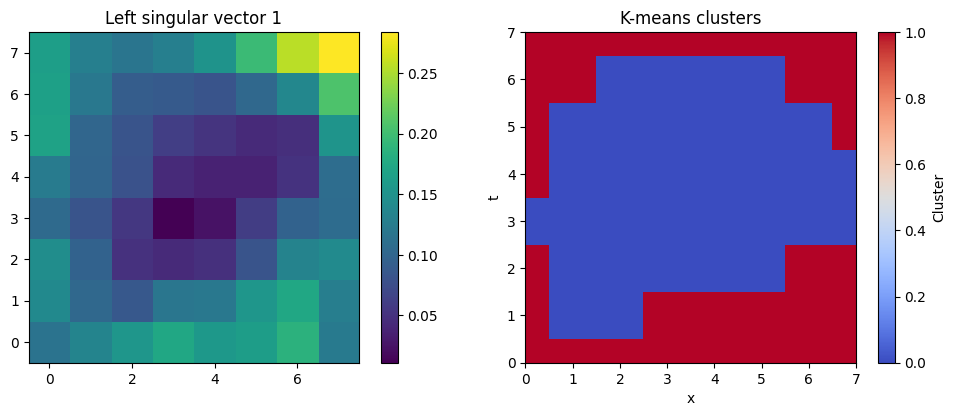

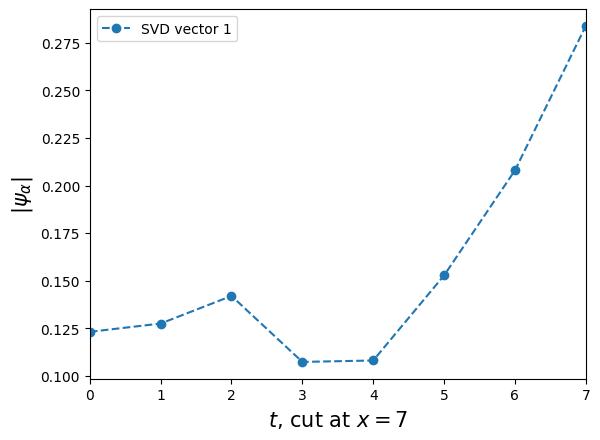

In [4]:
tvID = 1
xlims = [0,x_elements-1]
tlims = [0,t_elements-1]
make_heatmap_and_k_cluster(low_rank_tv1,xlims,tlims,tvID,"k_means_0001.pdf",False)
#Plot of a cut
cut = 7
X = np.arange(0,low_rank_tv1.shape[0])
plt.plot(X,np.abs(low_rank_tv1[:,cut,tvID]),marker='o',linestyle='--',label='SVD vector {0}'.format(tvID))
plt.legend()
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.xlabel(r"$t$, cut at $x=${0}".format(cut),size=15)
plt.xlim(tlims)
plt.show()

In [ ]:
fig_name = "heatmaps_blockID{0}_bsize{1}_beta{2}.pdf".format(blockID,x_elements,beta)
metadata = [Nx, Nt, beta, m0_diff, x_elements,blockID, k_rank, NV,SAP_block_size]
save=False
make_heatmaps(low_rank_tv0, low_rank_tv1,xlims,tlims,metadata,fig_name,save)

In [ ]:
for confID in range(5):
    params_list = [beta, m0_str, m0_folder, confID, NV, Nx, Nt]
    #Apply both filters
    for which_mask in [0,1]:
        masked_test_vectors = mask_vectors(k_rank,block_x,block_t,which_mask,params_list)
        #save_vectors(masked_test_vectors,beta,Nx,Nt,m0_folder,confID,k_rank,which_mask)
#print(masked_test_vectors.shape)

In [ ]:
for confID in range(5):
    params_list = [beta, m0_str, m0_folder, confID, NV, Nx, Nt]
    masked_test_vectors = mask_vectors(k_rank,block_x,block_t,5,params_list)
    save_vectors(masked_test_vectors,beta,Nx,Nt,m0_folder,confID,k_rank,0)

In [ ]:
tvID = 0
block_size_x = x_elements
block_size_t = t_elements

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(1, 2, 2)
im = ax.imshow(np.abs((masked_test_vectors[tvID,0,:,:])))
ax.set_xlabel(r"x")
ax.set_ylabel(r"t")
ax.set_xlim([0,63])
ax.set_ylim([0,63])
ax.set_title("Heatmap of masked SVD vector")
ax.set_xticks(np.arange(-0.5, Nx, block_size_x), minor=True)
ax.set_yticks(np.arange(-0.5, Nt, block_size_t), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.figure.colorbar(im, ax=ax)

#test_vectors = read_vectors(params_list)
lsv = svd_vectors_full_range(k_rank,block_x,block_t,params_list)
ax = plt.subplot(1, 2, 1)
im = ax.imshow(2*np.abs((lsv[tvID,0,:,:])))
ax.set_xlabel(r"x")
ax.set_ylabel(r"t")
ax.set_xlim([0,63])
ax.set_ylim([0,63])
ax.set_title("Heatmap of SVD vector")
ax.set_xticks(np.arange(-0.5, Nx, block_size_x), minor=True)
ax.set_yticks(np.arange(-0.5, Nt, block_size_t), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.figure.colorbar(im, ax=ax)
#fig.savefig("heatmap_comparison.pdf")



blockID = 0
params_list = [beta, m0_str, m0_folder, nconf, NV, Nx, Nt]
dtv_spin0, dtv_spin1 = read_and_decompose(blockID,block_x,block_t,params_list)
print("\nSpin component 0")
low_rank_tv0 = apply_SVD(dtv_spin0,k_rank)
#low_rank_tv0 = low_rank_tv0.reshape(t_elements,x_elements,NV);
low_rank_tv0 = low_rank_tv0.reshape(t_elements,x_elements,k_rank);

xlims = [0,x_elements-1]
tlims = [0,t_elements-1]
make_heatmap_and_k_cluster(low_rank_tv0,xlims,tlims,tvID)

In [ ]:
#ID = 0
#for x in range(Nx):
#    for t in range(Nt):
#        mask = np.abs((masked_test_vectors[ID,0,t,x]))
#        not_mask = np.abs((test_vectors[ID,0,t,x]))
#        if np.abs(mask-not_mask) > 1e-2:
#            print("x={0}, t={1}, mask_vec_norm={2}, not_mask_norm={3}".format(x,t,mask,not_mask))

In [ ]:
save = False
tvID = 3
block_size_x = x_elements
block_size_t = t_elements
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(1, 1, 1)
im = ax.imshow(np.abs((masked_test_vectors[tvID,0,:,:])))
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
ax.set_xlim([0,63])
ax.set_ylim([0,63])
ax.set_title("Left singular vector {0}".format(tvID))
ax.set_xticks(np.arange(-0.5, Nx, block_size_x), minor=True)
ax.set_yticks(np.arange(-0.5, Nt, block_size_t), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.figure.colorbar(im, ax=ax)
if save == True:
    fig.savefig("lsv_not_filtered_{0}.pdf".format(tvID))

In [ ]:
tvID = 0
block_size_x = x_elements
block_size_t = t_elements


svd_vectors = mask_vectors(k_rank,block_x,block_t,5,params_list)
high_freq = mask_vectors(k_rank,block_x,block_t,0,params_list)
low_freq = mask_vectors(k_rank,block_x,block_t,1,params_list)

fig = plt.figure(figsize=(18, 6))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(np.abs((svd_vectors[tvID,0,:,:])))
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
ax.set_xlim([0,63])
ax.set_ylim([0,63])
ax.set_title("Heatmap of SVD vector")
ax.set_xticks(np.arange(-0.5, Nx, block_size_x), minor=True)
ax.set_yticks(np.arange(-0.5, Nt, block_size_t), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.figure.colorbar(im, ax=ax)

ax = plt.subplot(1, 3, 2)
im = ax.imshow(np.abs((high_freq[tvID,0,:,:])))
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
ax.set_xlim([0,63])
ax.set_ylim([0,63])
ax.set_title("Heatmap of high frequency components")
ax.set_xticks(np.arange(-0.5, Nx, block_size_x), minor=True)
ax.set_yticks(np.arange(-0.5, Nt, block_size_t), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.figure.colorbar(im, ax=ax)

ax = plt.subplot(1, 3, 3)
im = ax.imshow(np.abs((low_freq[tvID,0,:,:])))
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
ax.set_xlim([0,63])
ax.set_ylim([0,63])
ax.set_title("Heatmap of low frequency components")
ax.set_xticks(np.arange(-0.5, Nx, block_size_x), minor=True)
ax.set_yticks(np.arange(-0.5, Nt, block_size_t), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
ax.figure.colorbar(im, ax=ax)
#fig.savefig("heatmap_comparison_high_low.pdf")